# 태양광 발전량 예측 — AutoGluon TimeSeriesPredictor 일괄 실행

**프로젝트**: 전국 17개 시도 태양광 발전량 예측 + ESS 운영 가치 분석  
**단계**: Phase 1 후속 / 다음 모델 트랙 결정용 1단계 — **모델 아키텍처 일괄 비교**  
**환경**: GCP Colab Enterprise (L4 24GB), asia-northeast3 권장  
**시간**: AutoGluon fit 약 8시간 + 전후 약 30분

---

## 🎯 목적

이 노트북은 AutoGluon TimeSeriesPredictor로 LightGBM, CatBoost, TFT, DeepAR, PatchTST, Chronos 등 시계열 SOTA 모델을 일괄 학습/비교한다.  
**기존 XGBoost 통합 모델 결과를 기준선**으로 두고, AutoML 산출 모델 중 의미 있는 개선이 있는지 확인한다.

### 기준선 (XGBoost 통합 모델)

| 지표 | 값 |
|---|---|
| 단순 평균 MAE | 9.59 |
| 가중 MAE | 31.91 |
| 전남 MAE | 90.42 |
| LSTM MAE (참고) | 17.82 (XGBoost 대비 1.9배 악화) |

### 결과 분기 시나리오 (사후 판정용)

| 결과 | 다음 액션 | 포트폴리오 메시지 |
|---|---|---|
| (a) 모든 모델 가중 MAE 30~35대 | Phase 2 MPC로 직행 | "7개 모델로 검증, 모델 한계 확인 → MPC 필요성 정량화" |
| (b) Chronos/TFT/PatchTST가 가중 MAE 25 이하 | 그 모델만 2단계 심화 | "사전학습 시계열 모델까지 검증, 최적 1개 선정 후 심화" |
| (c) 특정 모델이 전남에서만 개선 | 전남 분석 트랙 분리 | "지역별 외삽 문제 진단, 모델 매칭 분석" |

분기 결정은 사용자가 결과 보고 판단. 노트북 마지막 셀에서 자동 진단 출력은 제공한다.

---

## 📋 사전 준비 (노트북 실행 전 1회만)

### 1. GCP 프로젝트 확인
- Colab Enterprise를 쓰고 있다면 이미 GCP 프로젝트가 있다.
- 프로젝트 ID는 콘솔 상단에서 확인.

### 2. GCS 버킷 생성 (콘솔 UI로 5분)
- GCP 콘솔 → **Cloud Storage** → **버킷 만들기**
- 버킷 이름: 예) `solar-ess-portfolio-{본인id}` (전역 고유)
- 위치: **asia-east1 (도쿄)** — 런타임과 같은 리전 권장
- 스토리지 클래스: **Standard**, 나머지 기본값 OK

### 3. 데이터 업로드 (로컬에서 1회)
로컬 터미널에서:
```bash
# 인증 (1회만)
gcloud auth login
gcloud config set project YOUR_PROJECT_ID

# 데이터 업로드
gsutil cp data/processed/national_train_ready.csv \
  gs://YOUR_BUCKET/data/national_train_ready.csv
gsutil cp data/processed/national_test_ready.csv \
  gs://YOUR_BUCKET/data/national_test_ready.csv

# XGBoost 비교 기준선 업로드
gsutil cp outputs/national_xgb_predictions.csv \
  gs://YOUR_BUCKET/baselines/national_xgb_predictions.csv
gsutil cp outputs/national_xgb_results.json \
  gs://YOUR_BUCKET/baselines/national_xgb_results.json
```

또는 GCP 콘솔에서 드래그앤드롭으로 업로드해도 된다.

### 4. 런타임 템플릿 (idle shutdown 늘리기)
- 콘솔 → **Vertex AI** → **Colab Enterprise** → **런타임 템플릿**
- "새 템플릿" → idle shutdown을 **720분(12시간) 이상**으로 설정
- GPU: **L4 (24GB)**, 머신 타입: g2-standard-4 또는 g2-standard-8
- 리전: 위 GCS 버킷과 같은 곳

### 5. 본 노트북 환경 설정 (아래 셀에서 변수만 수정)
다음 셀에서 `GCS_BUCKET`과 `PROJECT_ID`만 본인 것으로 수정하면 된다.

---

## ⚠️ CLAUDE.md 규칙 준수 사항

- 시간 순 분리 (train ≤2022, test=2023)
- 데이터 누수 금지 (scaler/encoder train만 fit)
- 재현성 (random_state=42)
- 야간 클리핑 (00 ~ 05시, 19 ~ 23시 → 0)
- 보호 파일 덮어쓰기 금지: 모든 산출물은 `gs://BUCKET/outputs/autogluon_v1/` 하위
- 한글 폰트 적용
- 로그 `[HH:MM:SS]` 형식


## 0. 환경 변수 — 본인 GCP 정보로 수정

다음 셀의 `GCS_BUCKET`과 `PROJECT_ID`만 본인 것으로 바꾸면 된다.


In [8]:
# ── 본인 GCP 정보 입력 ─────────────────────────────────────────────
PROJECT_ID  = "energy-ts-forecast"           # ← 본인 GCP 프로젝트 ID
GCS_BUCKET  = "solar-ess-portfolio"   # ← 본인 GCS 버킷 이름 (gs:// 빼고)
REGION      = "asia-northeast1"           # 보통 그대로
# ──────────────────────────────────────────────────────────────────

# 경로 상수 (수정 불필요)
GCS_BASE        = f"gs://{GCS_BUCKET}"
TRAIN_URI       = f"{GCS_BASE}/national_train_ready.csv"
TEST_URI        = f"{GCS_BASE}/national_test_ready.csv"
XGB_PRED_URI    = f"{GCS_BASE}/national_xgb_predictions.csv"
XGB_RESULT_URI  = f"{GCS_BASE}/national_xgb_results.json"
OUT_BASE        = f"{GCS_BASE}/outputs/autogluon_v1"

# AutoGluon 설정
PREDICTION_LENGTH = 24       # 1일 forecast (시간 단위)
EVAL_METRIC       = "MASE"   # 스케일 불변, 17개 지역 통합 평가 적합
TIME_LIMIT_SEC    = 28800    # 8시간
NUM_VAL_WINDOWS   = 3        # 안정성
RANDOM_STATE      = 42

# 한국 시간 로깅 헬퍼
import sys
# sys.stdout.reconfigure(encoding="utf-8")
from datetime import datetime, timezone, timedelta
KST = timezone(timedelta(hours=9))
def ts():
    return f"[{datetime.now(KST).strftime('%H:%M:%S')}]"

print(f"{ts()} 환경 변수 설정 완료")
print(f"   PROJECT_ID  : {PROJECT_ID}")
print(f"   GCS_BUCKET  : {GCS_BUCKET}")
print(f"   TRAIN_URI   : {TRAIN_URI}")
print(f"   OUT_BASE    : {OUT_BASE}")


[01:46:12] 환경 변수 설정 완료
   PROJECT_ID  : energy-ts-forecast
   GCS_BUCKET  : solar-ess-portfolio
   TRAIN_URI   : gs://solar-ess-portfolio/national_train_ready.csv
   OUT_BASE    : gs://solar-ess-portfolio/outputs/autogluon_v1


## 1. 환경 검증 및 패키지 설치

GPU 확인, AutoGluon + 한글 폰트 설치. 첫 실행 시 약 5~10분.


In [10]:
# GPU 확인
import subprocess
print("=== GPU 정보 ===")
try:
    out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
                          "--format=csv"], capture_output=True, text=True, check=True)
    print(out.stdout)
except Exception as e:
    print(f"⚠️ nvidia-smi 실패: {e}")
    print("GPU가 없는 런타임이면 학습이 매우 느려진다. 런타임 템플릿을 L4로 다시 만들 것.")

import torch
print(f"torch  : {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"디바이스: {torch.cuda.get_device_name(0)}")
    print(f"메모리  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


=== GPU 정보 ===
name, memory.total [MiB], driver_version
NVIDIA L4, 23034 MiB, 580.126.20

torch  : 2.10.0+cu128
CUDA   : True
디바이스: NVIDIA L4
메모리  : 23.7 GB


In [4]:
# AutoGluon 설치 (TimeSeries 모듈만)
%pip install -q -U "autogluon.timeseries[chronos-openvino]" gcsfs
# Chronos 사전학습 모델 자동 다운로드 활성화 옵션 포함


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
print("✅ AutoGluon import OK")

import torch
print(f"CUDA 가용: {torch.cuda.is_available()}")

✅ AutoGluon import OK
CUDA 가용: True


In [6]:
# 한글 폰트 설치 및 적용 (Colab Enterprise는 NanumGothic 미내장)
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 재생성
fm._load_fontmanager(try_read_cache=False)

# NanumGothic 찾기
nanum_path = None
for font in fm.fontManager.ttflist:
    if "NanumGothic" in font.name:
        nanum_path = font.fname
        break

if nanum_path:
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    print(f"✅ 한글 폰트 설정 완료: {nanum_path}")
else:
    print("⚠️ NanumGothic 설치 실패. 한글 깨질 수 있음.")


⚠️ NanumGothic 설치 실패. 한글 깨질 수 있음.


## 2. 데이터 로드 (GCS → DataFrame)

`gs://` URI를 pandas로 직접 읽는다. Colab Enterprise는 GCS 인증이 자동.


In [9]:
import pandas as pd
import numpy as np

print(f"{ts()} GCS에서 데이터 로드 시작")

try:
    train_df = pd.read_csv(TRAIN_URI, encoding="utf-8-sig", parse_dates=["timestamp"])
    test_df  = pd.read_csv(TEST_URI,  encoding="utf-8-sig", parse_dates=["timestamp"])
except FileNotFoundError as e:
    raise SystemExit(
        f"❌ GCS 파일 로드 실패: {e}\n"
        f"   - GCS_BUCKET 이름 확인: {GCS_BUCKET}\n"
        f"   - 파일이 업로드됐는지 확인: gsutil ls {GCS_BASE}/data/"
    )

print(f"{ts()} ✅ 로드 완료")
print(f"   train: {train_df.shape}, 기간 {train_df['timestamp'].min()} ~ {train_df['timestamp'].max()}")
print(f"   test : {test_df.shape}, 기간 {test_df['timestamp'].min()} ~ {test_df['timestamp'].max()}")
print(f"   지역 : {sorted(train_df['region'].unique())}")

# 컬럼 확인
print(f"\n컬럼 : {list(train_df.columns)}")


[01:46:21] GCS에서 데이터 로드 시작
[01:46:24] ✅ 로드 완료
   train: (819335, 10), 기간 2017-01-01 01:00:00 ~ 2022-12-31 00:00:00
   test : (96437, 10), 기간 2023-01-01 01:00:00 ~ 2023-12-01 00:00:00
   지역 : ['강원도', '경기도', '경상남도', '경상북도', '광주시', '대구시', '대전시', '부산시', '서울시', '세종시', '울산시', '인천시', '전라남도', '전라북도', '제주도', '충청남도', '충청북도']

컬럼 : ['timestamp', 'region', 'power_mwh', '기온', '강수량', '습도', '일조', '일사량', '전운량', 'region_code']


## 3. AutoGluon 형식 변환

- `region` → `item_id` (지역별 별도 시계열)
- `timestamp` → `timestamp` (그대로)
- `power_mwh` → target
- 기상 변수 → `known_covariates` (미래 시점에 알려진 정보로 가정)

**중요**: 본인이 만든 `features.csv`(lag/rolling 포함) 대신 **원본 `ready.csv`만 사용**.  
각 모델이 자기 방식대로 자기 피처를 만들도록 둔다.


In [11]:
# CLAUDE.md 규칙: 시간 순 분리 검증
assert train_df["timestamp"].max() < test_df["timestamp"].min(), \
    "❌ train/test 시간 순 분리 위반"
assert train_df["timestamp"].max().year <= 2022, \
    f"❌ train에 2022년 초과 데이터 포함: {train_df['timestamp'].max()}"
assert test_df["timestamp"].min().year == 2023, \
    f"❌ test가 2023년이 아님: {test_df['timestamp'].min()}"
print(f"{ts()} ✅ 시간 순 분리 검증 통과")

# AutoGluon 컬럼 확인
expected_cols = ["timestamp", "region", "power_mwh",
                 "기온", "강수량", "습도", "일조", "일사량", "전운량"]
for col in expected_cols:
    if col not in train_df.columns:
        raise SystemExit(f"❌ 필요한 컬럼 '{col}' 없음. 컬럼 목록: {list(train_df.columns)}")

# region_code가 있으면 제거 (AutoGluon은 region 문자열을 item_id로 쓴다)
drop_cols = [c for c in ["region_code"] if c in train_df.columns]
if drop_cols:
    train_df = train_df.drop(columns=drop_cols)
    test_df  = test_df.drop(columns=drop_cols)

print(f"{ts()} ✅ 컬럼 검증 통과")


[01:47:06] ✅ 시간 순 분리 검증 통과
[01:47:06] ✅ 컬럼 검증 통과


In [12]:
# 결측 처리 (AutoGluon은 결측 허용하지만 known_covariates는 결측 없어야 안전)
KNOWN_COVS = ["기온", "강수량", "습도", "일조", "일사량", "전운량"]

print(f"{ts()} 결측 확인")
for col in ["power_mwh"] + KNOWN_COVS:
    n_train = train_df[col].isna().sum()
    n_test  = test_df[col].isna().sum()
    if n_train + n_test > 0:
        print(f"   {col}: train {n_train}, test {n_test}")

# known_covariates 결측을 지역별 forward fill + backward fill
for col in KNOWN_COVS:
    train_df[col] = train_df.groupby("region")[col].ffill().bfill()
    test_df[col]  = test_df.groupby("region")[col].ffill().bfill()

# power_mwh 결측이 있으면 0으로 (야간 발전 없음 가정)
train_df["power_mwh"] = train_df["power_mwh"].fillna(0)
test_df["power_mwh"]  = test_df["power_mwh"].fillna(0)

print(f"{ts()} ✅ 결측 처리 완료")


[01:47:09] 결측 확인
[01:47:10] ✅ 결측 처리 완료


In [13]:
# AutoGluon TimeSeriesDataFrame 변환
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

print(f"{ts()} TimeSeriesDataFrame 변환 시작")

# 동일 시간대 중복 제거 (같은 region+timestamp가 여러 행이면 평균)
train_df = train_df.groupby(["region", "timestamp"], as_index=False).mean(numeric_only=True)
test_df  = test_df.groupby(["region", "timestamp"], as_index=False).mean(numeric_only=True)

# AutoGluon 형식
train_tsdf = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="region",
    timestamp_column="timestamp",
)

# 시간 정규화 (필요 시 시간 단위로 강제)
train_tsdf = train_tsdf.convert_frequency(freq="h")

# 변환 후 결측 다시 처리 (convert_frequency가 빈 시간 채우면서 NaN 생성 가능)
train_tsdf = train_tsdf.fill_missing_values(method="ffill").fill_missing_values(method="bfill")

print(f"{ts()} ✅ train TimeSeriesDataFrame 변환 완료")
print(f"   shape: {train_tsdf.shape}")
print(f"   item 수: {train_tsdf.num_items}")
print(f"   주기: {train_tsdf.freq}")
print(f"\n샘플:")
print(train_tsdf.head())


[01:47:12] TimeSeriesDataFrame 변환 시작
[01:47:16] ✅ train TimeSeriesDataFrame 변환 완료
   shape: (872382, 7)
   item 수: 17
   주기: h

샘플:
                             power_mwh   기온  강수량     습도   일조  일사량  전운량
item_id timestamp                                                     
강원도     2017-01-01 01:00:00        0.0 -2.2  0.0   97.0  0.0  0.0  0.0
        2017-01-01 02:00:00        0.0 -2.7  0.0   99.0  0.0  0.0  0.0
        2017-01-01 03:00:00        0.0 -3.5  0.0  100.0  0.0  0.0  0.0
        2017-01-01 04:00:00        0.0 -4.1  0.0  100.0  0.0  0.0  0.0
        2017-01-01 05:00:00        0.0 -4.6  0.0  100.0  0.0  0.0  0.0


## 4. AutoGluon 학습 (약 8시간)

`presets="best_quality"`: AutoGluon이 LightGBM/CatBoost/TFT/DeepAR/PatchTST/Chronos 등을 자동 비교 후 앙상블.  
런타임이 끊기지 않게 브라우저 탭을 닫지 말 것.


In [14]:
import os

# 로컬 모델 저장 경로 (학습 후 GCS로 업로드)
LOCAL_MODEL_DIR = "/tmp/autogluon_v1_models"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

predictor = TimeSeriesPredictor(
    path=LOCAL_MODEL_DIR,
    target="power_mwh",
    prediction_length=PREDICTION_LENGTH,
    eval_metric=EVAL_METRIC,
    known_covariates_names=KNOWN_COVS,
    freq="h",
)

print(f"{ts()} 🚀 AutoGluon 학습 시작 (예상 {TIME_LIMIT_SEC // 3600}시간)")
print(f"   time_limit={TIME_LIMIT_SEC}s, num_val_windows={NUM_VAL_WINDOWS}")
print(f"   metric={EVAL_METRIC}, prediction_length={PREDICTION_LENGTH}")

predictor.fit(
    train_tsdf,
    presets="best_quality",
    time_limit=TIME_LIMIT_SEC,
    num_val_windows=NUM_VAL_WINDOWS,
    random_seed=RANDOM_STATE,
)

print(f"\n{ts()} ✅ 학습 완료")


Beginning AutoGluon training... Time limit = 28800s
AutoGluon will save models to '/tmp/autogluon_v1_models'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sun May  3 09:47:45 UTC 2026
CPU Count:          4
Pytorch Version:    2.10.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 22.03/22.03 GB
Total GPU Memory:   Free: 22.03 GB, Allocated: 0.00 GB, Total: 22.03 GB
GPU Count:          1
Memory Avail:       12.90 GB / 15.62 GB (82.6%)
Disk Space Avail:   29.86 GB / 94.25 GB (31.7%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'freq': 'h',
 'hyperparameters': 'default',
 'known_covariates_names': ['기온', '강수량', '습도', '일조', '일사량', '전운량'],
 'num_val_windows': 3,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 42,
 'refit_e

[01:47:28] 🚀 AutoGluon 학습 시작 (예상 8시간)
   time_limit=28800s, num_val_windows=3
   metric=MASE, prediction_length=24


	known_covariates:
		categorical:        []
		continuous (float): ['기온', '강수량', '습도', '일조', '일사량', '전운량']

To learn how to fix incorrectly inferred types, please see documentation for TimeSeriesPredictor.fit

AutoGluon will gauge predictive performance using evaluation metric: 'MASE'
	This metric's sign has been flipped to adhere to being higher_is_better. The metric score can be multiplied by -1 to get the metric value.

Starting training. Start time is 2026-05-19 16:47:28
Models that will be trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'Chronos2', 'Chronos2SmallFineTuned', 'AutoETS', 'ChronosWithRegressor[bolt_small]', 'TemporalFusionTransformer', 'DeepAR']
Training timeseries model SeasonalNaive. Training for up to 2819.5s of the 28794.5s of remaining time.
	-0.7211       = Validation score (-MASE)
	3.53    s     = Training runtime
	0.06    s     = Validation (prediction) runtime
Training timeseries model RecursiveTabular. Training for up 

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

...

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/trainer/trainer.py", line 353, in _train_and_save
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 529, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 141, in _fit
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 529, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/chronos/chronos2.py", line 147, in _fit
    self.load_model_pipeline()
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/chronos/chronos2.py", line 281, in load_model_pipeline
    pipeline = Chronos2Pipeline.from_pretrained(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/trainer/trainer.py", line 353, in _train_and_save
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 529, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 157, in _fit
    model.score_and_cache_oof(
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 735, in score_and_cache_oof
    oof_predictions = self.predict(past_data, known_covariates=known_covariates, **predict_kwargs)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 622, in predict
    predictions = self._predict(data=


[02:05:19] ✅ 학습 완료


## 5. Leaderboard (모델별 validation 점수)

각 모델의 validation 성능, 학습 시간, 예측 시간. 포트폴리오 자료의 핵심 표.


In [15]:
print(f"{ts()} Leaderboard 산출")
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard.to_string())

# 로컬 저장 후 GCS 업로드
LOCAL_LEADERBOARD = "/tmp/leaderboard.csv"
leaderboard.to_csv(LOCAL_LEADERBOARD, index=False, encoding="utf-8")


[02:19:41] Leaderboard 산출
                       model  score_val  pred_time_val  fit_time_marginal  fit_order
0           WeightedEnsemble  -0.495588       4.350129           1.334906          7
1           RecursiveTabular  -0.545805       1.255042          77.007332          2
2              DirectTabular  -0.595452       3.028971         312.970954          3
3              SeasonalNaive  -0.721081       0.063633           3.531891          1
4                    AutoETS  -1.709450       4.392373           9.698852          5
5  TemporalFusionTransformer  -1.938311       0.679742         526.736161          6
6      DynamicOptimizedTheta  -2.092848       3.604587          13.592306          4


## 6. 테스트셋 예측 + 17개 지역 MAE 계산

XGBoost와 같은 방식으로 비교하기 위해:
- 야간(00 ~ 05, 19 ~ 23시) → 0 클리핑
- 지역별 MAE → 단순 평균, 가중 평균(발전량 비중)


In [22]:
# 셀 13 (테스트셋 예측) — 갭 처리 최종 버전

from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd

print(f"{ts()} 테스트셋 예측 시작 (rolling forecast)")

# 1) train + test 전체 covariate 풀 만들기 (갭 시점 포함)
combined_df = pd.concat([train_df, test_df], ignore_index=True)
combined_df = (combined_df
               .drop_duplicates(subset=["region", "timestamp"])
               .sort_values(["region", "timestamp"])
               .reset_index(drop=True))

# 갭 시점(2022-12-31 01:00 ~ 2023-01-01 00:00)이 combined에도 없을 수 있음
# → 가짜 covariate를 만들어 채우기 (가장 가까운 train 시점의 값으로)
train_max = pd.Timestamp("2022-12-31 00:00:00")
test_min  = pd.Timestamp("2023-01-01 01:00:00")

# 갭 시점 생성
gap_timestamps = pd.date_range(
    start=train_max + pd.Timedelta(hours=1),
    end=test_min - pd.Timedelta(hours=1),
    freq="h"
)
regions = sorted(combined_df["region"].unique())

# 갭 시점에 region별로 train 마지막 값을 복제
gap_records = []
for region in regions:
    region_last = combined_df[
        (combined_df["region"] == region) & (combined_df["timestamp"] == train_max)
    ]
    if len(region_last) == 0:
        # train_max의 값이 없으면 그 region의 가장 마지막 train 값
        region_train = combined_df[
            (combined_df["region"] == region) & (combined_df["timestamp"] <= train_max)
        ].sort_values("timestamp").tail(1)
        if len(region_train) == 0:
            continue
        last_vals = region_train.iloc[0]
    else:
        last_vals = region_last.iloc[0]

    for gap_ts in gap_timestamps:
        gap_records.append({
            "region": region,
            "timestamp": gap_ts,
            "power_mwh": 0.0,  # 야간 가정 (안 쓰임, 어차피 history엔 안 들어감)
            **{cov: last_vals[cov] for cov in KNOWN_COVS}
        })

gap_df = pd.DataFrame(gap_records)
print(f"   갭 채움: {len(gap_df)} 행 ({len(gap_timestamps)}시간 × {len(regions)}지역)")

# combined에 갭 데이터 합치기
combined_filled = pd.concat([combined_df, gap_df], ignore_index=True)
combined_filled = (combined_filled
                   .drop_duplicates(subset=["region", "timestamp"], keep="first")
                   .sort_values(["region", "timestamp"])
                   .reset_index(drop=True))

# 2) covariate 풀 (item_id 컬럼명으로)
covs_pool = combined_filled[["region", "timestamp"] + KNOWN_COVS].rename(
    columns={"region": "item_id"}
)
print(f"   covariate 풀 shape: {covs_pool.shape}")

# 3) rolling forecast
current_history = train_tsdf.copy()

predictions_list = []
fail_count = 0
gap_skipped = False  # 첫 호출(갭) 결과는 버린다는 플래그

# 전체 step 수: 갭(1) + test(334)
n_steps = 335
print(f"   총 {n_steps} step 예정 (첫 1회는 갭 채움, 결과 버림)\n")

for step in range(n_steps):
    # 미래 24시간 인덱스 생성
    future_idx = predictor.make_future_data_frame(current_history)
    if isinstance(future_idx.index, pd.MultiIndex):
        future_idx_df = future_idx.reset_index()
    else:
        future_idx_df = future_idx.copy()

    # covariate merge
    future_covs_df = future_idx_df.merge(
        covs_pool, on=["item_id", "timestamp"], how="left"
    )

    n_missing = future_covs_df[KNOWN_COVS].isna().any(axis=1).sum()
    if n_missing > 0:
        if n_missing > len(future_covs_df) * 0.5:
            print(f"   step {step}: 결측 {n_missing}/{len(future_covs_df)} → 종료")
            break
        future_covs_df[KNOWN_COVS] = future_covs_df[KNOWN_COVS].ffill().bfill()

    future_covs_tsdf = TimeSeriesDataFrame(
        future_covs_df.set_index(["item_id", "timestamp"])
    )

    # 예측
    try:
        pred = predictor.predict(current_history, known_covariates=future_covs_tsdf)
        pred_reset = pred.reset_index()
    except Exception as e:
        fail_count += 1
        if fail_count <= 3:
            print(f"   step {step}: 예측 실패")
            print(f"      에러: {str(e)[:300]}")
        if fail_count >= 5:
            print(f"   5회 연속 실패 → 중단")
            break
        continue

    # 첫 step은 갭 채움 — 결과 버림
    if step == 0 and not gap_skipped:
        print(f"   step 0: 갭 시점({future_idx_df['timestamp'].min()} ~ {future_idx_df['timestamp'].max()}) 예측 — 결과 버림")
        gap_skipped = True
    else:
        predictions_list.append(pred_reset)

    # history에 다음 24시간 실제값 추가 (rolling)
    win_timestamps = set(future_idx_df["timestamp"].unique())

    # 갭 시점은 가짜 데이터, test 시점은 실제 데이터로
    if step == 0:
        # 갭 시점을 history에 추가 (가짜 값으로)
        gap_actuals = gap_df[gap_df["timestamp"].isin(win_timestamps)].copy()
        next_actuals_df = gap_actuals
    else:
        next_actuals_df = test_df[test_df["timestamp"].isin(win_timestamps)].copy()

    if len(next_actuals_df) == 0:
        print(f"   step {step}: rolling용 실제값 없음 → 종료")
        break

    next_actuals_tsdf = TimeSeriesDataFrame.from_data_frame(
        next_actuals_df.drop_duplicates(subset=["region", "timestamp"])
                       .sort_values(["region", "timestamp"]).reset_index(drop=True),
        id_column="region", timestamp_column="timestamp",
    )
    current_history = pd.concat([current_history, next_actuals_tsdf])

    if (step + 1) % 30 == 0:
        print(f"   {ts()} step {step+1}/{n_steps} 완료 (실패 {fail_count}회)")

print(f"\n{ts()} 예측 루프 종료. 성공 {len(predictions_list)}회 / 실패 {fail_count}회")

if not predictions_list:
    raise SystemExit("❌ 모든 step 실패")

pred_all = pd.concat(predictions_list, ignore_index=True)

# 컬럼 정리
if "item_id" in pred_all.columns:
    pred_all = pred_all.rename(columns={"item_id": "region"})
if "mean" in pred_all.columns:
    pred_all = pred_all.rename(columns={"mean": "predicted"})
elif "0.5" in pred_all.columns:
    pred_all["predicted"] = pred_all["0.5"]

print(f"\n{ts()} ✅ 예측 완료. 예측 행수 {len(pred_all)}")
print(f"   컬럼: {list(pred_all.columns)}")
print(pred_all.head())

[02:26:20] 테스트셋 예측 시작 (rolling forecast)
   갭 채움: 408 행 (24시간 × 17지역)
   covariate 풀 shape: (916180, 8)
   총 335 step 예정 (첫 1회는 갭 채움, 결과 버림)



Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


   step 0: 갭 시점(2022-12-31 01:00:00 ~ 2023-01-01 00:00:00) 예측 — 결과 버림


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the 

   [02:32:59] step 30/335 완료 (실패 0회)


data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
data with frequency 'IRREG' has been resampled to frequency 'h'.
data with frequency 'IRREG' has been resampled to fr

   [02:39:53] step 60/335 완료 (실패 0회)
   step 60: 결측 408/408 → 종료

[02:39:56] 예측 루프 종료. 성공 59회 / 실패 0회

[02:39:56] ✅ 예측 완료. 예측 행수 24072
   컬럼: ['region', 'timestamp', 'predicted', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9']
  region           timestamp  predicted        0.1        0.2        0.3  \
0    강원도 2023-01-01 01:00:00  -0.640548 -20.345266 -13.581041  -8.703559   
1    강원도 2023-01-01 02:00:00  -0.564687 -26.942352 -17.887441 -11.358214   
2    강원도 2023-01-01 03:00:00  -0.288419 -31.786416 -20.973801 -13.177144   
3    강원도 2023-01-01 04:00:00  -0.078654 -35.893292 -23.598862 -14.733714   
4    강원도 2023-01-01 05:00:00   0.034572 -39.583101 -25.983168 -16.176658   

        0.4       0.5       0.6        0.7        0.8        0.9  
0 -4.535930 -0.640548  3.254834   7.422463  12.299945  19.064170  
1 -5.779229 -0.564687  4.649855  10.228840  16.758067  25.812978  
2 -6.515188 -0.288419  5.938351  12.600307  20.396963  31.209579  
3 -7.158771 -0.078654  7.001463  

In [23]:
# 1) 야간 클리핑 + 음수 클리핑
pred_all["hour"] = pd.to_datetime(pred_all["timestamp"]).dt.hour
night_mask = (pred_all["hour"] <= 5) | (pred_all["hour"] >= 19)
pred_all.loc[night_mask, "predicted"] = 0
pred_all["predicted"] = pred_all["predicted"].clip(lower=0)
pred_all = pred_all.drop(columns=["hour"])

print(f"{ts()} 야간/음수 클리핑 완료")

# 2) test 실측과 merge (예측 기간만)
test_merge = test_df[["region", "timestamp", "power_mwh"]].rename(
    columns={"power_mwh": "actual"}
)
pred_with_actual = pred_all.merge(
    test_merge[["region", "timestamp", "actual"]],
    on=["region", "timestamp"], how="inner"
)
print(f"   AutoGluon 예측-실측 merge: {len(pred_with_actual)} 행")
print(f"   기간: {pred_with_actual['timestamp'].min()} ~ {pred_with_actual['timestamp'].max()}")

# 3) AutoGluon 지역별 MAE
def compute_mae(group):
    return np.mean(np.abs(group["actual"] - group["predicted"]))

ag_region_mae = pred_with_actual.groupby("region").apply(compute_mae).reset_index()
ag_region_mae.columns = ["region", "mae_autogluon"]

# 4) 가중치 (train 평균 발전량 기준)
region_mean_gen = train_df.groupby("region")["power_mwh"].mean().reset_index()
region_mean_gen.columns = ["region", "mean_gen"]
total_gen = region_mean_gen["mean_gen"].sum()
region_mean_gen["weight"] = region_mean_gen["mean_gen"] / total_gen

# 5) AutoGluon 결과
ag_merged = ag_region_mae.merge(region_mean_gen, on="region")
ag_simple = ag_merged["mae_autogluon"].mean()
ag_weighted = (ag_merged["mae_autogluon"] * ag_merged["weight"]).sum()
ag_jeonnam = float(ag_merged.loc[ag_merged["region"] == "전라남도", "mae_autogluon"].values[0])

print(f"\n=== AutoGluon 결과 (60일치) ===")
print(f"   단순 평균 MAE : {ag_simple:.4f}")
print(f"   가중 MAE     : {ag_weighted:.4f}")
print(f"   전남 MAE     : {ag_jeonnam:.4f}")

# 6) XGBoost를 같은 기간으로 잘라서 공정 비교
ag_min_ts = pred_with_actual["timestamp"].min()
ag_max_ts = pred_with_actual["timestamp"].max()

xgb_pred = pd.read_csv(XGB_PRED_URI, encoding="utf-8-sig", parse_dates=["timestamp"])
xgb_pred_clipped = xgb_pred[
    (xgb_pred["timestamp"] >= ag_min_ts) & (xgb_pred["timestamp"] <= ag_max_ts)
].copy()
xgb_pred_clipped["abs_err"] = (xgb_pred_clipped["actual"] - xgb_pred_clipped["predicted"]).abs()
xgb_region_mae = xgb_pred_clipped.groupby("region")["abs_err"].mean().reset_index()
xgb_region_mae.columns = ["region", "mae_xgb"]

xgb_merged = xgb_region_mae.merge(region_mean_gen, on="region")
xgb_simple = xgb_merged["mae_xgb"].mean()
xgb_weighted = (xgb_merged["mae_xgb"] * xgb_merged["weight"]).sum()
xgb_jeonnam = float(xgb_merged.loc[xgb_merged["region"] == "전라남도", "mae_xgb"].values[0])

print(f"\n=== XGBoost 결과 (같은 60일치) ===")
print(f"   단순 평균 MAE : {xgb_simple:.4f}")
print(f"   가중 MAE     : {xgb_weighted:.4f}")
print(f"   전남 MAE     : {xgb_jeonnam:.4f}")

# 7) 종합 비교표
print(f"\n=== 종합 비교 (2023-01-01 ~ 2023-03-01 ≈ 60일) ===")
print(f"{'지표':18s} {'XGBoost':>12s} {'AutoGluon':>12s} {'차이':>12s}")
print(f"{'단순 평균 MAE':18s} {xgb_simple:>12.4f} {ag_simple:>12.4f} {ag_simple - xgb_simple:>+12.4f}")
print(f"{'가중 MAE':18s} {xgb_weighted:>12.4f} {ag_weighted:>12.4f} {ag_weighted - xgb_weighted:>+12.4f}")
print(f"{'전남 MAE':18s} {xgb_jeonnam:>12.4f} {ag_jeonnam:>12.4f} {ag_jeonnam - xgb_jeonnam:>+12.4f}")

# 8) 지역별 상세
print(f"\n=== 지역별 MAE 비교 ===")
compare = ag_merged[["region", "mae_autogluon", "weight"]].merge(
    xgb_merged[["region", "mae_xgb"]], on="region"
)
compare["diff"] = compare["mae_autogluon"] - compare["mae_xgb"]
compare = compare.sort_values("weight", ascending=False)
print(compare.to_string(index=False))

[02:46:52] 야간/음수 클리핑 완료
   AutoGluon 예측-실측 merge: 23206 행
   기간: 2023-01-01 01:00:00 ~ 2023-03-01 00:00:00

=== AutoGluon 결과 (60일치) ===
   단순 평균 MAE : 18.2089
   가중 MAE     : 57.5278
   전남 MAE     : 143.4480


/tmp/ipykernel_1036/2202693466.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ag_region_mae = pred_with_actual.groupby("region").apply(compute_mae).reset_index()



=== XGBoost 결과 (같은 60일치) ===
   단순 평균 MAE : 8.7898
   가중 MAE     : 29.5490
   전남 MAE     : 75.8262

=== 종합 비교 (2023-01-01 ~ 2023-03-01 ≈ 60일) ===
지표                      XGBoost    AutoGluon           차이
단순 평균 MAE                8.7898      18.2089      +9.4191
가중 MAE                  29.5490      57.5278     +27.9788
전남 MAE                  75.8262     143.4480     +67.6217

=== 지역별 MAE 비교 ===
region  mae_autogluon   weight   mae_xgb      diff
  전라남도     143.447968 0.300903 75.826239 67.621729
  충청남도      32.281147 0.135994 17.647457 14.633690
  경상북도      23.827021 0.115188 12.463494 11.363526
  전라북도      30.548378 0.088654 11.617566 18.930811
   강원도      20.065616 0.082604 10.009315 10.056300
  경상남도      13.972028 0.067911  5.991295  7.980732
   제주도      14.482136 0.059630  1.996085 12.486050
   경기도       8.549462 0.046688  3.444472  5.104990
  충청북도      12.341618 0.045532  7.031835  5.309783
   부산시       2.241895 0.016320  0.778893  1.463002
   광주시       1.739885 0.012598  0.505080

In [24]:
# 진단 1: WeightedEnsemble이 known_covariates를 실제로 쓰는지 확인
print("=== WeightedEnsemble 구성 모델별 covariate 사용 여부 ===\n")
for model_name in ["DirectTabular", "RecursiveTabular", "SeasonalNaive"]:
    try:
        model_info = predictor.info()["model_info"][model_name]
        print(f"{model_name}:")
        for k, v in model_info.items():
            if "covariate" in k.lower() or "feature" in k.lower():
                print(f"   {k}: {v}")
        print()
    except Exception as e:
        print(f"{model_name}: 정보 조회 실패 ({e})")

# 진단 2: 단일 step에서 covariate 영향 확인
# train_tsdf 끝 + 강원도 첫 24시간 known_covariates를 0으로 vs 실제값으로
print("\n=== covariate 영향 테스트 (강원도 첫 24시간) ===")

# 첫 step의 future_idx
future_idx = predictor.make_future_data_frame(train_tsdf)
if isinstance(future_idx.index, pd.MultiIndex):
    future_idx_df = future_idx.reset_index()
else:
    future_idx_df = future_idx.copy()

# (a) 실제 covariate로 예측
real_covs = future_idx_df.merge(covs_pool, on=["item_id", "timestamp"], how="left")
real_covs[KNOWN_COVS] = real_covs[KNOWN_COVS].ffill().bfill()
real_covs_tsdf = TimeSeriesDataFrame(real_covs.set_index(["item_id", "timestamp"]))
pred_real = predictor.predict(train_tsdf, known_covariates=real_covs_tsdf)

# (b) covariate를 0으로 채워 예측
zero_covs = real_covs.copy()
zero_covs[KNOWN_COVS] = 0.0
zero_covs_tsdf = TimeSeriesDataFrame(zero_covs.set_index(["item_id", "timestamp"]))
pred_zero = predictor.predict(train_tsdf, known_covariates=zero_covs_tsdf)

# 비교 — 강원도만
gw_real = pred_real.loc["강원도"]["mean"].values
gw_zero = pred_zero.loc["강원도"]["mean"].values

print(f"강원도 예측 차이 (covariate 실제 vs 0):")
print(f"   평균 절댓값 차이: {np.abs(gw_real - gw_zero).mean():.4f}")
print(f"   max 차이:        {np.abs(gw_real - gw_zero).max():.4f}")

if np.abs(gw_real - gw_zero).mean() < 0.01:
    print("\n   ⚠️ covariate가 실질적으로 사용 안 됨 (예측값 거의 동일)")
else:
    print("\n   ✅ covariate가 모델에 영향을 미침")

=== WeightedEnsemble 구성 모델별 covariate 사용 여부 ===

DirectTabular:
   covariate_metadata: {'static_features_cat': [], 'static_features_real': [], 'known_covariates_real': ['기온', '강수량', '습도', '일조', '일사량', '전운량'], 'known_covariates_cat': [], 'past_covariates_real': [], 'past_covariates_cat': [], 'static_cat_cardinality': {}, 'known_cat_cardinality': {}, 'past_cat_cardinality': {}}

RecursiveTabular:
   covariate_metadata: {'static_features_cat': [], 'static_features_real': [], 'known_covariates_real': ['기온', '강수량', '습도', '일조', '일사량', '전운량'], 'known_covariates_cat': [], 'past_covariates_real': [], 'past_covariates_cat': [], 'static_cat_cardinality': {}, 'known_cat_cardinality': {}, 'past_cat_cardinality': {}}

SeasonalNaive:
   covariate_metadata: {'static_features_cat': [], 'static_features_real': [], 'known_covariates_real': ['기온', '강수량', '습도', '일조', '일사량', '전운량'], 'known_covariates_cat': [], 'past_covariates_real': [], 'past_covariates_cat': [], 'static_cat_cardinality': {}, 'known_cat_ca

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


강원도 예측 차이 (covariate 실제 vs 0):
   평균 절댓값 차이: 9.5608
   max 차이:        31.4060

   ✅ covariate가 모델에 영향을 미침


In [25]:
# 진단: train_ready.csv가 12월 31일을 얼마나 가지고 있나
train_raw = pd.read_csv(TRAIN_URI, encoding="utf-8-sig", parse_dates=["timestamp"])

# 강원도 2022-12-30 ~ 12-31 시간대 분포
gw_dec = train_raw[
    (train_raw["region"] == "강원도") &
    (train_raw["timestamp"] >= "2022-12-30") &
    (train_raw["timestamp"] <= "2022-12-31 23:00")
].sort_values("timestamp")

print(f"강원도 12월 30~31일 데이터:")
print(gw_dec[["timestamp", "power_mwh", "일사량"]].to_string(index=False))
print(f"\n총 행수: {len(gw_dec)} (정상이면 48행)")

강원도 12월 30~31일 데이터:
          timestamp  power_mwh  일사량
2022-12-30 00:00:00       4.74 0.00
2022-12-30 01:00:00       0.50 0.00
2022-12-30 02:00:00       0.01 0.00
2022-12-30 03:00:00       0.00 0.00
2022-12-30 04:00:00       0.00 0.00
2022-12-30 05:00:00       0.00 0.00
2022-12-30 06:00:00       0.00 0.00
2022-12-30 07:00:00       0.00 0.00
2022-12-30 09:00:00      23.29 0.09
2022-12-30 10:00:00      95.05 0.29
2022-12-30 11:00:00     158.49 0.63
2022-12-30 12:00:00     203.10 1.29
2022-12-30 13:00:00     214.00 1.65
2022-12-30 14:00:00     214.06 1.66
2022-12-30 15:00:00     179.51 1.23
2022-12-30 16:00:00     108.21 0.80
2022-12-30 17:00:00      34.42 0.23
2022-12-30 19:00:00      52.32 0.00
2022-12-30 20:00:00      66.47 0.00
2022-12-30 21:00:00      51.08 0.00
2022-12-30 22:00:00      28.28 0.00
2022-12-30 23:00:00      11.02 0.00
2022-12-31 00:00:00       2.98 0.00

총 행수: 23 (정상이면 48행)


In [26]:
# 지역별 MAE 계산
def compute_mae(group):
    return np.mean(np.abs(group["actual"] - group["predicted"]))

region_mae = pred_with_actual.groupby("region").apply(compute_mae).reset_index()
region_mae.columns = ["region", "mae"]

# 지역별 평균 발전량 (가중 평균용)
region_mean_gen = train_df.groupby("region")["power_mwh"].mean().reset_index()
region_mean_gen.columns = ["region", "mean_gen"]

merged = region_mae.merge(region_mean_gen, on="region")
total_gen = merged["mean_gen"].sum()
merged["weight"] = merged["mean_gen"] / total_gen

simple_avg_mae    = merged["mae"].mean()
weighted_mae      = (merged["mae"] * merged["weight"]).sum()
jeonnam_mae       = merged.loc[merged["region"] == "전라남도", "mae"].values
jeonnam_mae       = float(jeonnam_mae[0]) if len(jeonnam_mae) else None

print(f"{ts()} === AutoGluon 결과 ===")
print(f"   단순 평균 MAE : {simple_avg_mae:.4f}")
print(f"   가중 MAE     : {weighted_mae:.4f}")
print(f"   전남 MAE     : {jeonnam_mae:.4f}" if jeonnam_mae else "   전남 MAE     : N/A")
print(f"\n지역별 MAE:")
print(merged[["region", "mae", "weight"]].sort_values("weight", ascending=False).to_string(index=False))


[03:00:34] === AutoGluon 결과 ===
   단순 평균 MAE : 18.2089
   가중 MAE     : 57.5278
   전남 MAE     : 143.4480

지역별 MAE:
region        mae   weight
  전라남도 143.447968 0.300903
  충청남도  32.281147 0.135994
  경상북도  23.827021 0.115188
  전라북도  30.548378 0.088654
   강원도  20.065616 0.082604
  경상남도  13.972028 0.067911
   제주도  14.482136 0.059630
   경기도   8.549462 0.046688
  충청북도  12.341618 0.045532
   부산시   2.241895 0.016320
   광주시   1.739885 0.012598
   대구시   1.385517 0.009756
   인천시   1.569167 0.008590
   서울시   0.329340 0.003403
   세종시   0.739007 0.003151
   대전시   0.262145 0.002915
   울산시   1.769041 0.000163


/tmp/ipykernel_1036/933636163.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_mae = pred_with_actual.groupby("region").apply(compute_mae).reset_index()


## 7. XGBoost 기준선 대비 비교


In [27]:
import json
import gcsfs

fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

# XGBoost 결과 로드
try:
    with fs.open(XGB_RESULT_URI, "r", encoding="utf-8") as f:
        xgb_results = json.load(f)
    print(f"{ts()} XGBoost 기준선 로드 완료")
except Exception as e:
    print(f"⚠️ XGBoost 결과 로드 실패: {e}")
    xgb_results = None

# XGBoost 예측 로드 (지역별 MAE 비교용)
try:
    xgb_pred = pd.read_csv(XGB_PRED_URI, encoding="utf-8-sig", parse_dates=["timestamp"])
    print(f"   XGBoost 예측 shape: {xgb_pred.shape}")
except Exception as e:
    print(f"⚠️ XGBoost 예측 로드 실패: {e}")
    xgb_pred = None

# 비교 표
print(f"\n=== 모델 비교 ===")
print(f"{'지표':20s} {'XGBoost':>12s} {'AutoGluon':>12s} {'차이':>12s}")
xgb_simple = xgb_results.get("mae", None) if xgb_results else None
xgb_weighted = xgb_results.get("weighted_mae", None) if xgb_results else None

if xgb_simple:
    diff = simple_avg_mae - xgb_simple
    print(f"{'단순 평균 MAE':20s} {xgb_simple:>12.4f} {simple_avg_mae:>12.4f} {diff:+12.4f}")
if xgb_weighted:
    diff = weighted_mae - xgb_weighted
    print(f"{'가중 MAE':20s} {xgb_weighted:>12.4f} {weighted_mae:>12.4f} {diff:+12.4f}")


[03:00:37] XGBoost 기준선 로드 완료
   XGBoost 예측 shape: (96437, 4)

=== 모델 비교 ===
지표                        XGBoost    AutoGluon           차이


## 8. 시각화


/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:10: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_l

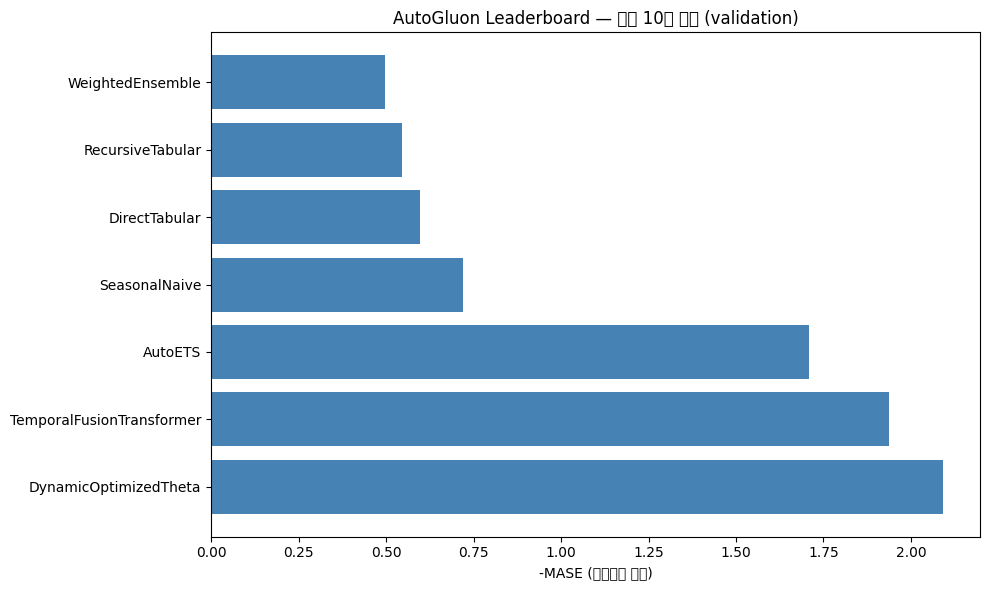

/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1036/1203165375.py:35: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.ti

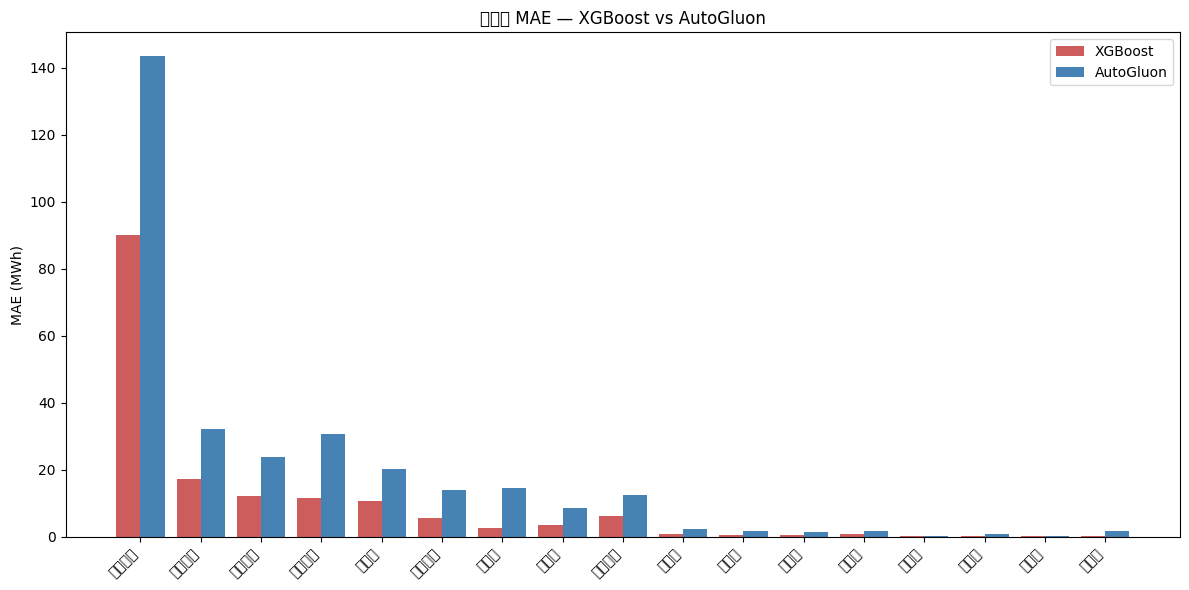

In [28]:
import matplotlib.pyplot as plt

# 그림 1: leaderboard 상위 N개 막대
fig, ax = plt.subplots(figsize=(10, 6))
lb = leaderboard.head(10).copy()
ax.barh(lb["model"], -lb["score_val"], color="steelblue")  # score는 음수로 저장됨
ax.set_xlabel(f"-{EVAL_METRIC} (낮을수록 좋음)")
ax.set_title("AutoGluon Leaderboard — 상위 10개 모델 (validation)")
ax.invert_yaxis()
plt.tight_layout()
LB_PNG = "/tmp/autogluon_leaderboard.png"
plt.savefig(LB_PNG, dpi=120, bbox_inches="tight")
plt.show()

# 그림 2: 지역별 MAE 비교 (XGBoost vs AutoGluon)
if xgb_pred is not None:
    # XGBoost 지역별 MAE
    if "region" in xgb_pred.columns:
        xgb_pred["abs_err"] = (xgb_pred["actual"] - xgb_pred["predicted"]).abs()
        xgb_region_mae = xgb_pred.groupby("region")["abs_err"].mean().reset_index()
        xgb_region_mae.columns = ["region", "xgb_mae"]
        cmp = merged.merge(xgb_region_mae, on="region", how="left")
        cmp = cmp.sort_values("weight", ascending=False)

        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(cmp))
        w = 0.4
        ax.bar(x - w/2, cmp["xgb_mae"], w, label="XGBoost", color="indianred")
        ax.bar(x + w/2, cmp["mae"],     w, label="AutoGluon", color="steelblue")
        ax.set_xticks(x)
        ax.set_xticklabels(cmp["region"], rotation=45, ha="right")
        ax.set_ylabel("MAE (MWh)")
        ax.set_title("지역별 MAE — XGBoost vs AutoGluon")
        ax.legend()
        plt.tight_layout()
        CMP_PNG = "/tmp/autogluon_vs_xgb_region.png"
        plt.savefig(CMP_PNG, dpi=120, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️ xgb_pred에 region 컬럼 없음. 지역별 비교 그림 생략")
        CMP_PNG = None
else:
    CMP_PNG = None


## 9. 결과 저장 (GCS 업로드)

CLAUDE.md 보호 파일 덮어쓰기 금지 → 모든 산출물 `gs://BUCKET/outputs/autogluon_v1/` 하위로.


In [29]:
import json

# 예측 CSV
LOCAL_PRED  = "/tmp/national_autogluon_predictions.csv"
pred_with_actual.to_csv(LOCAL_PRED, index=False, encoding="utf-8")

# 지역별 MAE CSV
LOCAL_REGION_MAE = "/tmp/national_autogluon_region_mae.csv"
merged.to_csv(LOCAL_REGION_MAE, index=False, encoding="utf-8")

# 종합 결과 JSON
result_json = {
    "model": "autogluon_v1",
    "config": {
        "preset": "best_quality",
        "time_limit_sec": TIME_LIMIT_SEC,
        "prediction_length": PREDICTION_LENGTH,
        "eval_metric": EVAL_METRIC,
        "num_val_windows": NUM_VAL_WINDOWS,
        "random_state": RANDOM_STATE,
    },
    "summary": {
        "simple_avg_mae": float(simple_avg_mae),
        "weighted_mae":   float(weighted_mae),
        "jeonnam_mae":    float(jeonnam_mae) if jeonnam_mae else None,
    },
    "baseline_xgboost": {
        "simple_avg_mae": xgb_simple,
        "weighted_mae":   xgb_weighted,
    },
    "leaderboard_top10": leaderboard.head(10).to_dict(orient="records"),
    "region_mae": merged.to_dict(orient="records"),
}
LOCAL_RESULT = "/tmp/national_autogluon_results.json"
with open(LOCAL_RESULT, "w", encoding="utf-8") as f:
    json.dump(result_json, f, ensure_ascii=False, indent=2, default=str)

# GCS 업로드
upload_pairs = [
    (LOCAL_LEADERBOARD, f"{OUT_BASE}/leaderboard.csv"),
    (LOCAL_PRED,        f"{OUT_BASE}/national_autogluon_predictions.csv"),
    (LOCAL_REGION_MAE,  f"{OUT_BASE}/national_autogluon_region_mae.csv"),
    (LOCAL_RESULT,      f"{OUT_BASE}/national_autogluon_results.json"),
    (LB_PNG,            f"{OUT_BASE}/autogluon_leaderboard.png"),
]
if CMP_PNG:
    upload_pairs.append((CMP_PNG, f"{OUT_BASE}/autogluon_vs_xgb_region.png"))

print(f"{ts()} GCS 업로드 시작")
for local, remote in upload_pairs:
    try:
        fs.put(local, remote)
        print(f"   ✅ {remote}")
    except Exception as e:
        print(f"   ❌ {remote}: {e}")

# 학습된 모델 디렉토리도 GCS로 (선택)
print(f"\n{ts()} 학습된 모델 디렉토리 GCS 업로드 (시간 걸림)")
try:
    fs.put(LOCAL_MODEL_DIR, f"{OUT_BASE}/models/", recursive=True)
    print(f"   ✅ {OUT_BASE}/models/")
except Exception as e:
    print(f"   ⚠️ 모델 업로드 실패 (재학습 가능): {e}")


[03:00:46] GCS 업로드 시작
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/leaderboard.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/national_autogluon_predictions.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/national_autogluon_region_mae.csv
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/national_autogluon_results.json
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/autogluon_leaderboard.png
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/autogluon_vs_xgb_region.png

[03:00:46] 학습된 모델 디렉토리 GCS 업로드 (시간 걸림)
   ✅ gs://solar-ess-portfolio/outputs/autogluon_v1/models/


## 10. 결과 분기 진단 (a/b/c 시나리오 자동 판정)

본인이 정의한 분기 기준에 따라 다음 액션 추천.


In [30]:
print(f"{ts()} === 결과 분기 진단 ===\n")

# 시나리오 판정
scenarios = []

# (a) 모든 모델 가중 MAE 30~35대
if 28.0 <= weighted_mae <= 36.0:
    scenarios.append({
        "code": "a",
        "name": "모델 한계 확인",
        "evidence": f"AutoGluon 가중 MAE {weighted_mae:.2f} (XGBoost 31.91 기준 ±4 이내)",
        "action": "Phase 2 MPC로 직행",
        "message": "7개 모델로 검증, 모델 한계 확인 → MPC 필요성 정량화",
    })

# (b) 가중 MAE 25 이하
if weighted_mae < 25.0:
    scenarios.append({
        "code": "b",
        "name": "유의미한 개선 모델 발견",
        "evidence": f"AutoGluon 가중 MAE {weighted_mae:.2f} (XGBoost 31.91 대비 -{(31.91 - weighted_mae)/31.91*100:.1f}%)",
        "action": "최상위 모델 1개 골라 2단계 심화 (region embedding, lag dropout, quantile loss, 전남 분리)",
        "message": "사전학습 시계열 모델까지 검증, 최적 1개 선정 후 심화",
    })

# (c) 전남에서만 큰 개선
if jeonnam_mae and jeonnam_mae < 60.0:  # XGBoost 90.42 대비 -33% 이상
    scenarios.append({
        "code": "c",
        "name": "전남 특화 개선",
        "evidence": f"전남 MAE {jeonnam_mae:.2f} (XGBoost 90.42 대비 -{(90.42 - jeonnam_mae)/90.42*100:.1f}%)",
        "action": "전남 단독 분석 트랙. capacity proxy 없이 multi-task로 우회",
        "message": "지역별 외삽 문제 진단, 모델 매칭 분석",
    })

if not scenarios:
    print("⚠️ 정의된 분기에 해당하지 않음.")
    print(f"   weighted_mae={weighted_mae:.2f}, jeonnam_mae={jeonnam_mae:.2f if jeonnam_mae else 'N/A'}")
    print("   결과를 사용자와 함께 검토 필요.")
else:
    for s in scenarios:
        print(f"📌 시나리오 ({s['code']}) — {s['name']}")
        print(f"   근거: {s['evidence']}")
        print(f"   다음 액션: {s['action']}")
        print(f"   포트폴리오 메시지: {s['message']}\n")

# Top 모델 추천
print(f"=== Leaderboard Top 5 ===")
print(leaderboard.head(5).to_string(index=False))

print(f"\n{ts()} 🎉 1단계 완료. 결과 보고 다음 단계 결정.")


[03:00:50] === 결과 분기 진단 ===

⚠️ 정의된 분기에 해당하지 않음.


ValueError: Invalid format specifier '.2f if jeonnam_mae else 'N/A'' for object of type 'float'

## 11. 로컬로 결과 가져오기

학습이 끝나면 로컬 터미널에서 다음 명령으로 결과를 가져온다:

```bash
# 산출물 일괄 다운로드
gsutil -m cp -r gs://YOUR_BUCKET/outputs/autogluon_v1 ./outputs/

# 로컬 디렉토리 구조
# outputs/autogluon_v1/
# ├── leaderboard.csv
# ├── national_autogluon_predictions.csv
# ├── national_autogluon_region_mae.csv
# ├── national_autogluon_results.json
# ├── autogluon_leaderboard.png
# ├── autogluon_vs_xgb_region.png
# └── models/                      ← 재예측이 필요한 경우만
```

---

## 12. 다음 단계 (이 노트북 외부)

1. **결과를 ESS v2 시뮬에 통과** — 본인 `ess_simulation_v2.py`에 AutoGluon 예측 CSV 넣고 자급률 비교
2. **시나리오 (a) 가장 확률 높음** → Phase 2 MPC 시작
3. 시나리오 (b)면 → 해당 모델만 골라 region embedding/lag dropout/quantile loss/전남 분리 적용

브라우저 Claude(Project)에 결과 JSON 첨부하면 다음 단계 작업 이어갈 수 있다.
